## VISUALIZATION

In this section we will visualize the results obtained within the backtesting simulation.

In [1]:
from plotnine import *
import pandas as pd

In [2]:
data = pd.read_csv('../data/processed/backtest_results.csv')

data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])

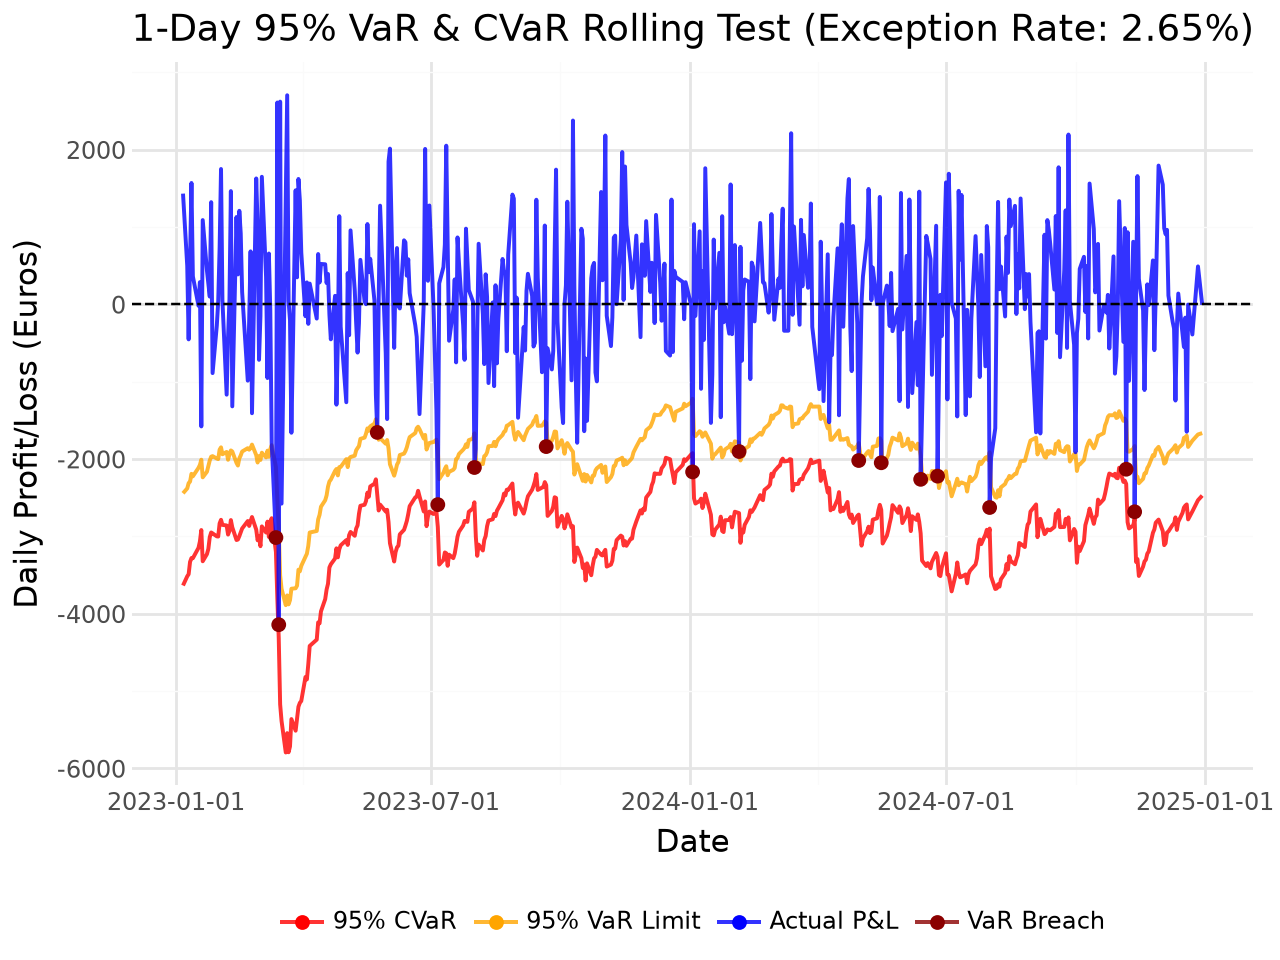

In [3]:
breaches_data = data[data['Breach'] == 1].copy()
breaches_data['Legend'] = 'VaR Breach' 

# This merges PnL and VaR columns into a single column called 'Series'
data_melted = data.melt(
	id_vars=['Date'], 
	value_vars=['Actual_PnL', 'VaR_95', 'CVaR_95'], 
	var_name='Series', 
	value_name='Euros'
)

data_melted['Series'] = data_melted['Series'].replace({
	'Actual_PnL': 'Actual P&L',
	'VaR_95': '95% VaR Limit',
	'CVaR_95': '95% CVaR'
})

# Plot
p = (ggplot()

	# Plots the Series
	+ geom_line(data_melted, aes(x='Date', y='Euros', color='Series'), size=0.8, alpha=0.8)
	# Plots the Breaches
	+ geom_point(breaches_data, aes(x='Date', y='Actual_PnL', color='Legend'), size=2)
	
	# The zero Line
	+ geom_hline(yintercept=0, linetype='dashed', color='black')
	
	# Link the exact text in our dataframes to specific colors
	+ scale_color_manual(
		name="",
		values={
			"Actual P&L": "blue", 
			"95% VaR Limit": "orange",
			"95% CVaR": "red",
			"VaR Breach": "darkred"
		}
	)
	
	+ labs(title="1-Day 95% VaR & CVaR Rolling Test (Exception Rate: 2.65%)", 
			x="Date", 
			y="Daily Profit/Loss (Euros)")
	+ theme_minimal()
	+ theme(legend_position='bottom')
	+ theme(legend_title = element_blank())
)

p

## OPTMIMIZER RESULTS

In [4]:
data = pd.read_csv('../data/processed/optimizer_results.csv')

data = data.reset_index()

data['Date'] = pd.to_datetime(data['Date'])

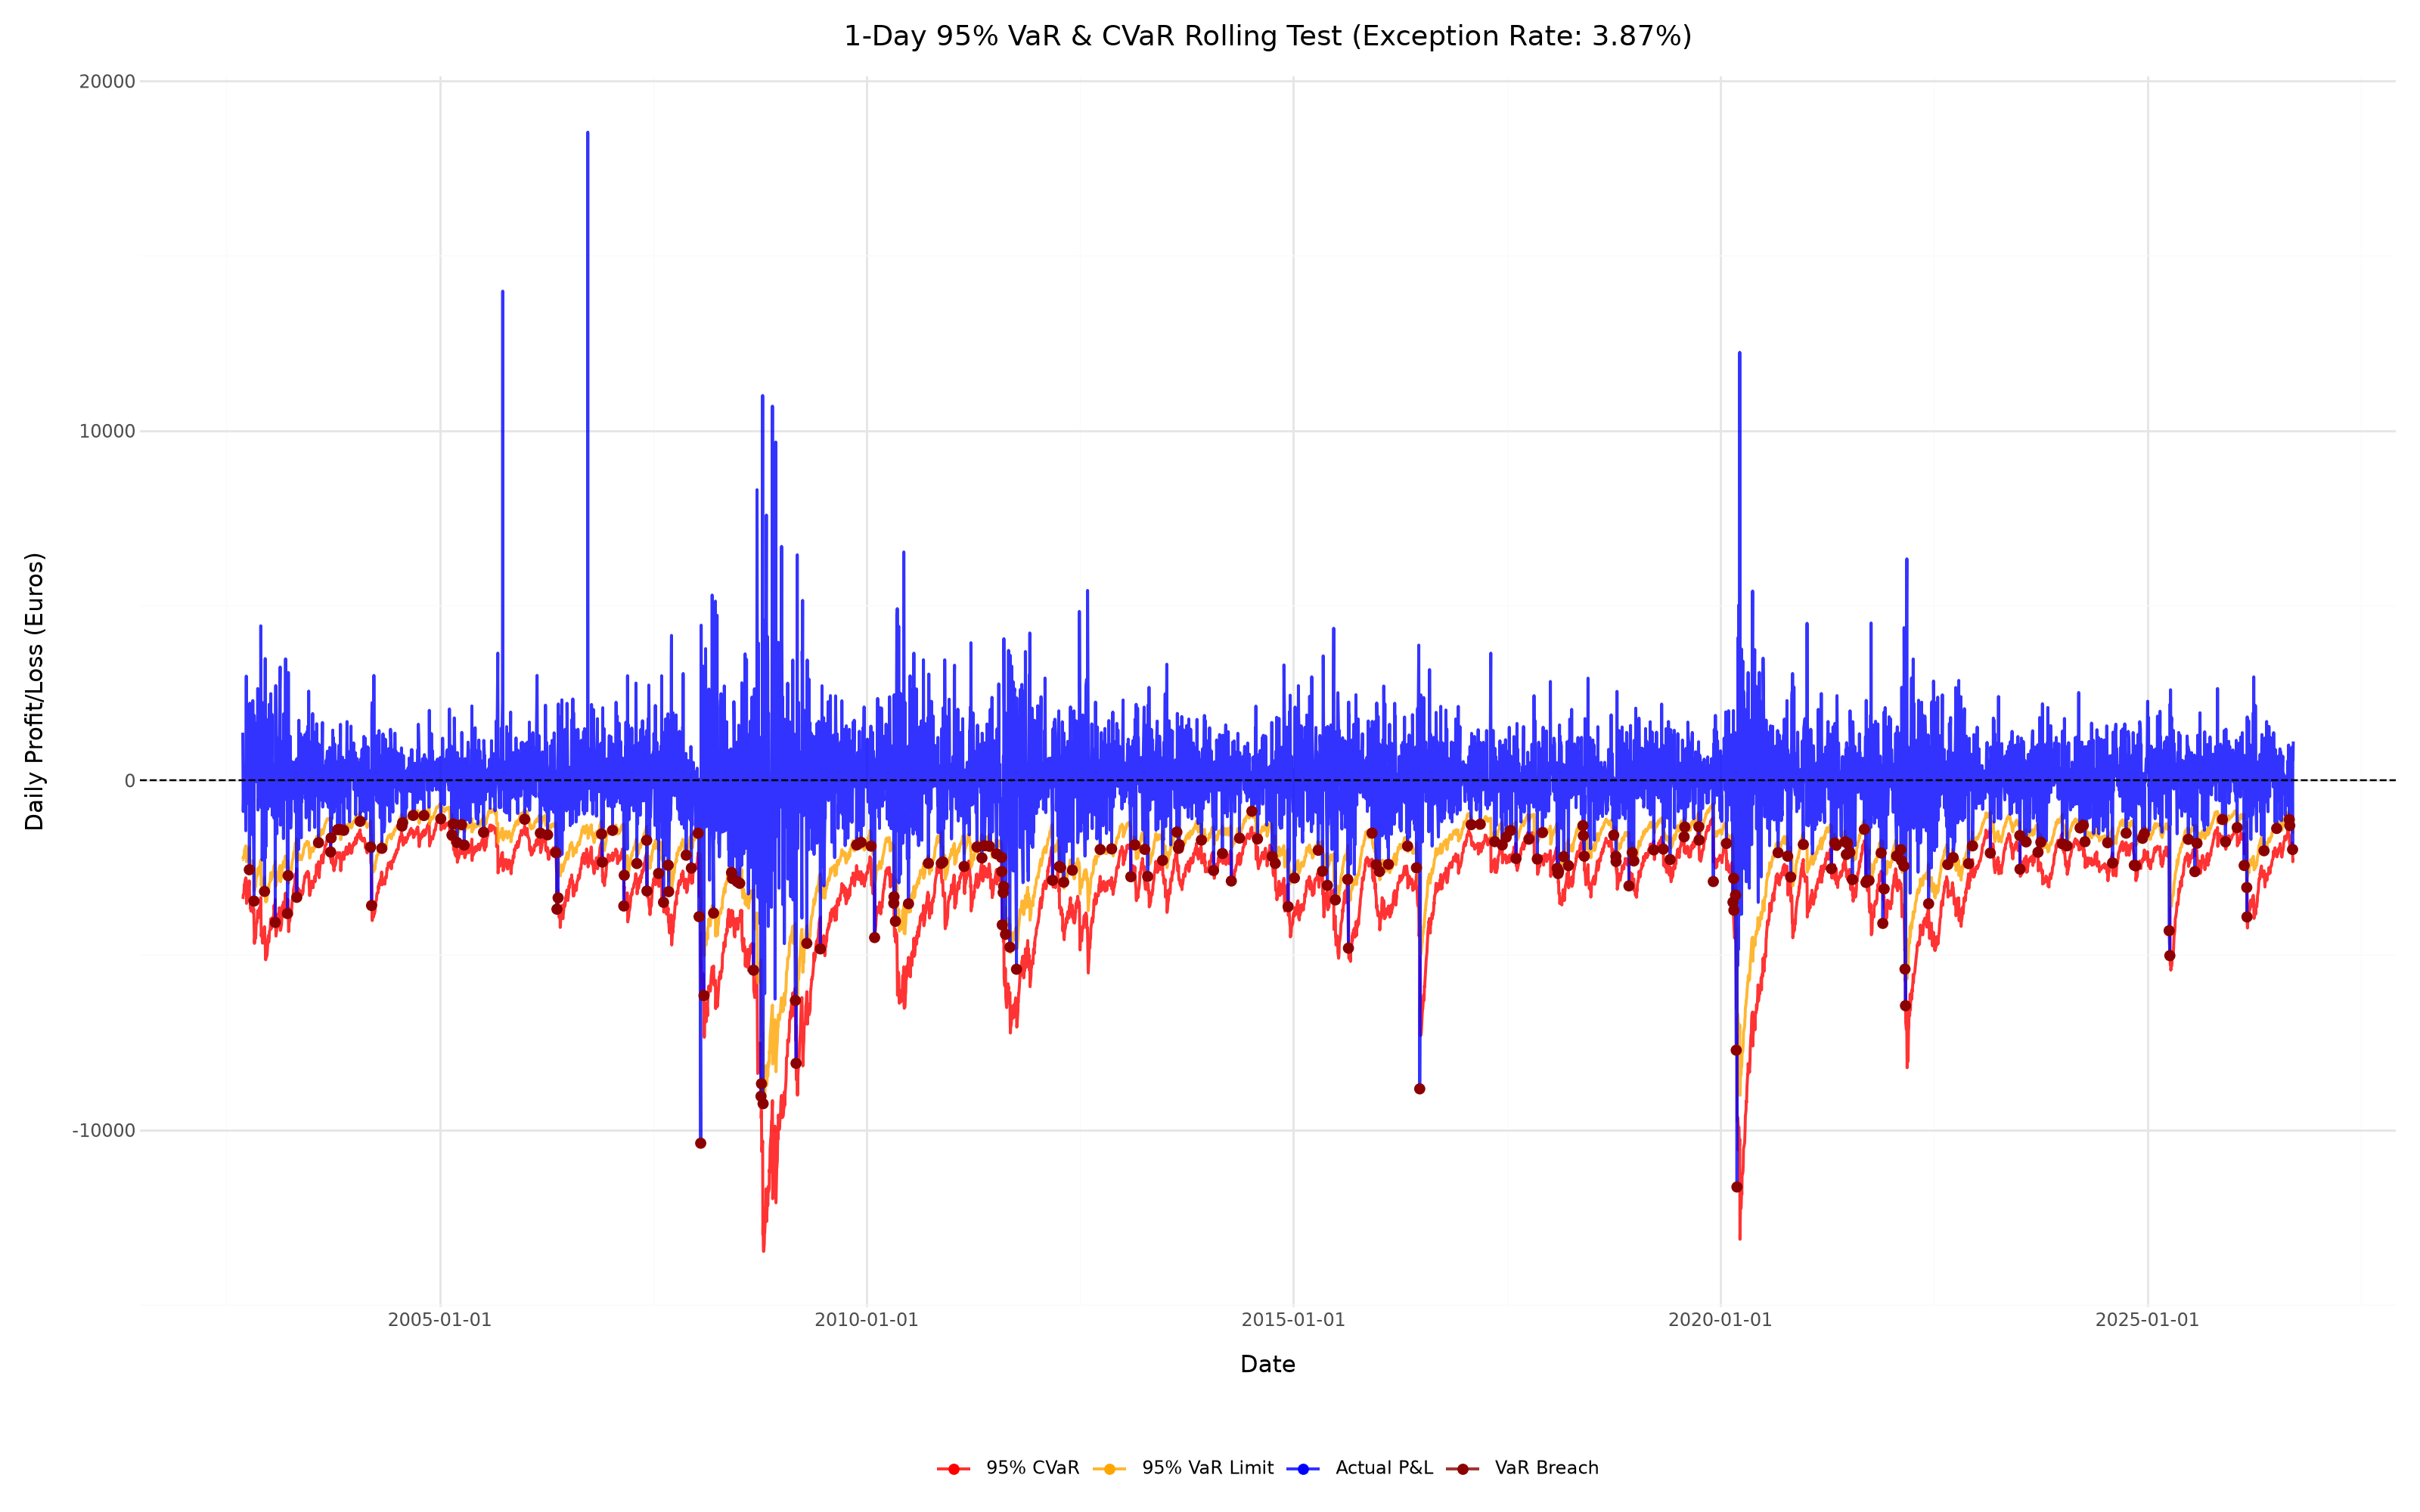

In [5]:
breaches_data = data[data['Breach'] == 1].copy()
breaches_data['Legend'] = 'VaR Breach' 

# This merges PnL and VaR columns into a single column called 'Series'
data_melted = data.melt(
	id_vars=['Date'], 
	value_vars=['Actual_PnL', 'VaR_95', 'CVaR_95'], 
	var_name='Series', 
	value_name='Euros'
)

data_melted['Series'] = data_melted['Series'].replace({
	'Actual_PnL': 'Actual P&L',
	'VaR_95': '95% VaR Limit',
	'CVaR_95': '95% CVaR'
})

# Plot
p = (ggplot()

	# Plots the Series
	+ geom_line(data_melted, aes(x='Date', y='Euros', color='Series'), size=0.8, alpha=0.8)
	# Plots the Breaches
	+ geom_point(breaches_data, aes(x='Date', y='Actual_PnL', color='Legend'), size=2)
	
	# The zero Line
	+ geom_hline(yintercept=0, linetype='dashed', color='black')
	
	# Link the exact text in our dataframes to specific colors
	+ scale_color_manual(
		name="",
		values={
			"Actual P&L": "blue", 
			"95% VaR Limit": "orange",
			"95% CVaR": "red",
			"VaR Breach": "darkred"
		}
	)
	
	+ labs(title="1-Day 95% VaR & CVaR Rolling Test (Exception Rate: 3.87%)", 
			x="Date", 
			y="Daily Profit/Loss (Euros)")
	+ theme_minimal()
	+ theme(legend_position='bottom')
	+ theme(legend_title = element_blank())
	+ theme(figure_size=(16, 10))
)

p

In [8]:
import plotly.graph_objects as go

fig = go.Figure()

# Actual P&L
fig.add_trace(go.Scatter(
    x=data['Date'], y=data['Actual_PnL'], 
    mode='lines', name='Actual PnL', 
    line=dict(color='blue', width=1), opacity=0.75
))

# 95% VaR Limit
fig.add_trace(go.Scatter(
    x=data['Date'], y=data['VaR_95'], 
    mode='lines', name='95% VaR Limit', 
    line=dict(color='orange', width=1.5)
))

# 95% CVaR
fig.add_trace(go.Scatter(
    x=data['Date'], y=data['CVaR_95'], 
    mode='lines', name='95% CVaR', 
    line=dict(color='red', width=1.5)
))

# The Breaches
fig.add_trace(go.Scatter(
    x=breaches_data['Date'], y=breaches_data['Actual_PnL'], 
    mode='markers', name='VaR Breach', 
    marker=dict(color='darkred', size=6)
))

# The Zero Line & Layout Formatting
fig.add_hline(y=0, line_dash="dash", line_color="black")

fig.update_layout(
    title="1-Day 95% VaR & CVaR Rolling Test (Exception Rate: 3.87%)",
    xaxis_title="Date",
    yaxis_title="Daily Profit/Loss (Euros)",
    template="plotly_white",
    hovermode="x unified", # Shows all values for a specific day when hovering
    legend=dict(
        orientation="h", # Horizontal legend
        yanchor="bottom", y=-0.25, 
        xanchor="center", x=0.5
    )
)

fig.show(renderer="browser")
